# Lab 1 - AI Model Design and Quantization
## Setup
### Install python package

In [5]:
%pip install torch
%pip install torchinfo
%pip install torchsummary
%pip install torchvision
%pip install tqdm
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

### Environment Setup

In [6]:
import os
import math
import copy
import time
import torch
import platform
import warnings
import numpy as np
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.ao.quantization as tq


from enum import Enum
from tqdm import tqdm
from typing import Tuple
from torchsummary import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
from torch.optim.lr_scheduler import _LRScheduler

DEFAULT_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

machine = platform.machine().lower()

if 'x86' in machine or 'amd64' in machine:
    torch.backends.quantized.engine = 'fbgemm'
elif 'arm' in machine or 'aarch64' in machine:
    torch.backends.quantized.engine = 'qnnpack'
else:
    print("Unsupported machine:", machine)

print("Pytorch version:", torch.__version__)
print(f"Using {torch.backends.quantized.engine} backend {machine}")
print("Using device:", DEFAULT_DEVICE)

Pytorch version: 2.10.0+cu128
Using fbgemm backend x86_64
Using device: cuda


### Load CIFAR-10 Dataset

In [7]:
def get_loaders(
    source, batch_size: int, transform, eval_transform=None,
    root: str = "data", split_ratio: float = 0.1
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    if eval_transform is None:
        eval_transform = transform

    trainset = source(root=root, train=True, download=True, transform=transform)
    testset  = source(root=root, train=False, download=True, transform=eval_transform)

    val_len = int(split_ratio * len(trainset))
    train_len = len(trainset) - val_len
    trainset, valset = torch.utils.data.random_split(trainset, [train_len, val_len])

    loader_kwargs = dict(batch_size=batch_size, num_workers=4, pin_memory=True)
    trainloader = DataLoader(trainset, shuffle=True, **loader_kwargs)
    valloader  = DataLoader(valset, shuffle=True, **loader_kwargs)
    testloader = DataLoader(testset, shuffle=False, **loader_kwargs)

    return trainloader, valloader, testloader

def get_cifar10_loaders(batch_size: int, root="data/cifar10", split_ratio=0.1):
    """
    Create CIFAR-10 training / validation / testing dataloaders.

    Args:
        batch_size (int): Number of samples per mini-batch.
        root (str): Path to download/load CIFAR-10 dataset.
        split_ratio (float): Fraction of training set to use for validation.

    Returns:
        train_loader, val_loader, test_loader (torch.utils.data.DataLoader)
    """

    # ----- Data augmentation for training -----
    train_transform = transforms.Compose([
        ##### YOUR CODE HERE #####
        # Data augmentation for training
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # mean, standard
    ])

    # ----- Evaluation transform -----
    eval_transform = transforms.Compose([
        ##### YOUR CODE HERE #####
        # Evaluation transform
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # mean, standard
    ])

    return get_loaders(
        datasets.CIFAR10, batch_size, train_transform,
        eval_transform=eval_transform, root=root, split_ratio=split_ratio
    )

if __name__ == "__main__":
    """ You can adjust the numbers below """
    BATCH_SIZE = 32
    VAL_TRAIN_SPLIT_RATIO = 0.1

    train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=BATCH_SIZE, split_ratio=VAL_TRAIN_SPLIT_RATIO)
    print(f"CIFAR-10: train={len(train_loader.dataset)}, "
            f"val={len(val_loader.dataset)}, "
            f"test={len(test_loader.dataset)}, "
            f"shape={train_loader.dataset[0][0].shape}")

100%|██████████| 170M/170M [01:01<00:00, 2.78MB/s]


CIFAR-10: train=45000, val=5000, test=10000, shape=torch.Size([3, 32, 32])


## Model Preparation
### Implement VGG

In [8]:
class VGG(nn.Module):
    """ Implement your VGG model here """
    def __init__(self, in_channels=3, in_size=32, num_classes=10) -> None:
        ##### YOUR CODE HERE #####
        super().__init__()

        self.quant = tq.QuantStub()

        self.features = nn.Sequential(
            # Conv1: 3 -> 64 (Idx: 0, 1, 2) + MaxPool (Idx: 3) (32x32 => 16x16)
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2: 64 -> 192 (Idx: 4, 5, 6) + MaxPool (Idx: 7) (16x16 => 8x8)
            nn.Conv2d(64, 192, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3: 192 -> 384 (Idx: 8, 9, 10)
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            # Conv4: 384 -> 256 (Idx: 11, 12, 13)
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Conv5: 256 -> 256 (Idx: 14, 15, 16) + MaxPool (Idx: 17) (8x8 => 4x4)
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # flat 256   4x4 feature => arr size 256*4*4 = 4096
        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            # FC6 (Idx: 0, 1)
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),

            # FC7 (Idx: 2, 3)
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),

            # FC8 (Idx: 4)
            nn.Linear(128, num_classes)
        )

        self.dequant = tq.DeQuantStub()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ##### YOUR CODE HERE #####
        x = self.quant(x)

        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)

        x = self.dequant(x)
        return x

    def fuse_model(self):
        ##### YOUR CODE HERE #####

        # fuse features   Conv + BN + ReLU
        tq.fuse_modules(self.features, [
            ['0', '1', '2'],       # Conv1
            ['4', '5', '6'],       # Conv2
            ['8', '9', '10'],      # Conv3
            ['11', '12', '13'],    # Conv4
            ['14', '15', '16']     # Conv5
        ], inplace=True)

        # fuse classifier  Linear + ReLU
        tq.fuse_modules(self.classifier, [
            ['0', '1'],            # FC6
            ['2', '3']             # FC7
        ], inplace=True)


### Inspect Model Architecture

In [9]:
if __name__ == "__main__":
    model = VGG()
    summary(model, (3, 32, 32), device= 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         QuantStub-1            [-1, 3, 32, 32]               0
            Conv2d-2           [-1, 64, 32, 32]           1,792
       BatchNorm2d-3           [-1, 64, 32, 32]             128
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
            Conv2d-6          [-1, 192, 16, 16]         110,784
       BatchNorm2d-7          [-1, 192, 16, 16]             384
              ReLU-8          [-1, 192, 16, 16]               0
         MaxPool2d-9            [-1, 192, 8, 8]               0
           Conv2d-10            [-1, 384, 8, 8]         663,936
      BatchNorm2d-11            [-1, 384, 8, 8]             768
             ReLU-12            [-1, 384, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         884,992
      BatchNorm2d-14            [-1, 25

## Utilities

In [10]:
def preprocess_filename(filename: str, existed: str = "keep_both") -> str:
    if existed == "overwrite":
        pass
    elif existed == "keep_both":
        base, ext = os.path.splitext(filename)
        cnt = 1
        while os.path.exists(filename):
            filename = f"{base}-{cnt}{ext}"
            cnt += 1
    elif existed == "raise" and os.path.exists(filename):
        raise FileExistsError(f"{filename} already exists.")
    else:
        raise ValueError(f"Unknown value for 'existed': {existed}")
    return filename

def plot_loss_accuracy(train_loss, train_acc, val_loss, val_acc, filename="loss_accuracy.png"):

    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.plot(train_loss, color="tab:blue")
    ax1.plot(val_loss, color="tab:red")
    ax1.legend(["Training", "Validation"])
    ax1.set_title("Loss")

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.plot(train_acc, color="tab:blue")
    ax2.plot(val_acc, color="tab:red")
    ax2.legend(["Training", "Validation"])
    ax2.set_title("Accuracy")

    fig.tight_layout()
    filename = preprocess_filename(filename)
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename)
    print(f"Plot saved at {filename}")

def plot_confusion_matrix(conf_matrix, filename="conf_matrix.png"):
    classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix for CIFAR-10 Classification")
    plt.tight_layout()

    filename = preprocess_filename(filename)
    plt.savefig(filename)
    print(f"Confusion matrix saved to {filename}")

def save_model(
    model, filename: str, verbose: bool = True, existed: str = "keep_both"
) -> None:
    filename = preprocess_filename(filename, existed)

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    torch.save(model.state_dict(), filename)
    if verbose:
        print(f"Model saved at {filename} ({os.path.getsize(filename) / 1e6} MB)")
    else:
        print(f"Model saved at {filename}")

def load_model(
    model, filename: str, qconfig=None, fuse_modules: bool = False, verbose: bool = True
) -> torch.nn.Module:
    if fuse_modules and hasattr(model, "fuse_module"):
        print("Fusing modules")
        model.to('cpu').eval()
        model.fuse_model()

    if qconfig is not None:
        model.qconfig = qconfig
        qconfig_dict = {"": qconfig}
        model2 = copy.deepcopy(model)
        model_prepared = tq.prepare(model2, qconfig_dict)
        model_int8 = tq.convert(model_prepared)
        model_int8.load_state_dict(torch.load(filename, map_location= 'cpu', weights_only=False))
        model_int8.eval()
    else:
        device = DEFAULT_DEVICE if qconfig is None else 'cpu'
        model.load_state_dict(torch.load(filename, map_location=device, weights_only=False))

    if verbose:
        print(f"Model loaded from {filename} ({os.path.getsize(filename) / 1e6} MB)")
    return model

## Train Model
### Evaluate Function

In [11]:
def evaluate(model, dataloader, criterion, device=DEFAULT_DEVICE):
    running_loss = 0
    total, correct = 0, 0
    all_preds, all_labels = [], []

    model.eval()
    with torch.no_grad():
        loop = tqdm(dataloader, desc="Evaluating", leave=True)

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)

            running_loss += loss.item()
            predicted = torch.argmax(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        loop.set_postfix(loss=running_loss / (total / images.shape[0]), accuracy=correct / total)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total * 100
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, conf_matrix

### Custom Learning Rate Scheduler (Optional)

In [ ]:
##### YOUR CODE HERE #####
# Optional: You can add more functions if needed.

### Training Loop

In [12]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.1, device=DEFAULT_DEVICE):
    """
    Train the model across multiple epochs and validate after each epoch.

    Args:
        model (nn.Module): Model to train.
        train_loader (DataLoader): Training data loader.
        val_loader (DataLoader): Validation data loader.
        epochs (int): Number of epochs to train.
        lr (float): Learning rate.
        device (str): Training device.

    Returns:
        model (nn.Module): Trained model.
    """

    ##### YOUR CODE HERE #####
    # Implement ypur criterion, optimizer, and scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr, momentum=0.9, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    train_loss_history, train_acc_history = [], []
    val_loss_history, val_acc_history = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            ##### YOUR CODE HERE #####
            # 1. Zero optimizer gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(images)

            # 3. Compute loss
            loss = criterion(outputs, labels)

            # 4. Backward pass
            loss.backward()

            # 5. Optimizer step
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({"loss": running_loss / total})

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        ##### YOUR CODE HERE #####
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = 100. * val_correct / val_total

        # Save history
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc / 100.0)

        print(f"Epoch {epoch+1} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_model(model, "./weights/best_vgg_cifar10.pth", existed="overwrite")

        ##### YOUR CODE HERE #####
        # Scheduler step
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

    # Plot after training
    plot_loss_accuracy( train_loss_history, train_acc_history, val_loss_history, val_acc_history, filename="./results/loss_accuracy.png")

    return model

### Hyperparameter Configuration

Epoch 1/75: 100%|██████████| 1407/1407 [00:29<00:00, 47.47it/s, loss=1.48]


Epoch 1 | Train Loss: 1.4807 | Train Acc: 45.55% | Val Loss: 1.2581 | Val Acc: 53.70%
Model saved at ./weights/best_vgg_cifar10.pth (13.371343 MB)


Epoch 2/75: 100%|██████████| 1407/1407 [00:25<00:00, 55.62it/s, loss=1.1]


Epoch 2 | Train Loss: 1.0959 | Train Acc: 61.24% | Val Loss: 1.0570 | Val Acc: 62.64%
Model saved at ./weights/best_vgg_cifar10.pth (13.371343 MB)


Epoch 3/75: 100%|██████████| 1407/1407 [00:26<00:00, 53.50it/s, loss=0.921]


...

Epoch 73 | Train Loss: 0.0058 | Train Acc: 99.89% | Val Loss: 0.3435 | Val Acc: 91.64%


Epoch 74/75: 100%|██████████| 1407/1407 [00:26<00:00, 52.22it/s, loss=0.00528]


Epoch 74 | Train Loss: 0.0053 | Train Acc: 99.92% | Val Loss: 0.3360 | Val Acc: 91.20%


Epoch 75/75: 100%|██████████| 1407/1407 [00:26<00:00, 52.63it/s, loss=0.0055]


Epoch 75 | Train Loss: 0.0055 | Train Acc: 99.90% | Val Loss: 0.3380 | Val Acc: 91.78%
Model saved at ./weights/best_vgg_cifar10.pth (13.371343 MB)
Plot saved at ./results/loss_accuracy.png


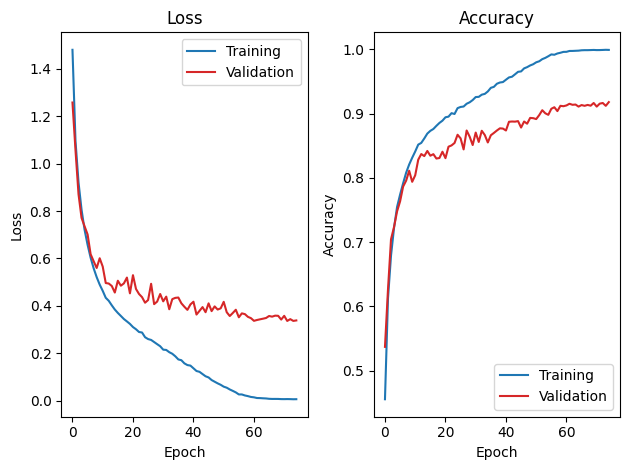

In [ ]:
if __name__ == "__main__":
    """ You can adjust the numbers below """
    EPOCHS = 75
    LEARNING_RATE = 0.01

    model = VGG().to(DEFAULT_DEVICE)
    train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)

### Model Testing

Evaluating: 100%|██████████| 313/313 [01:20<00:00,  3.87it/s]


Test Accuracy: 91.11% | Loss: 0.4043


FileNotFoundError: [Errno 2] No such file or directory: './results/confusion_matrix.png'

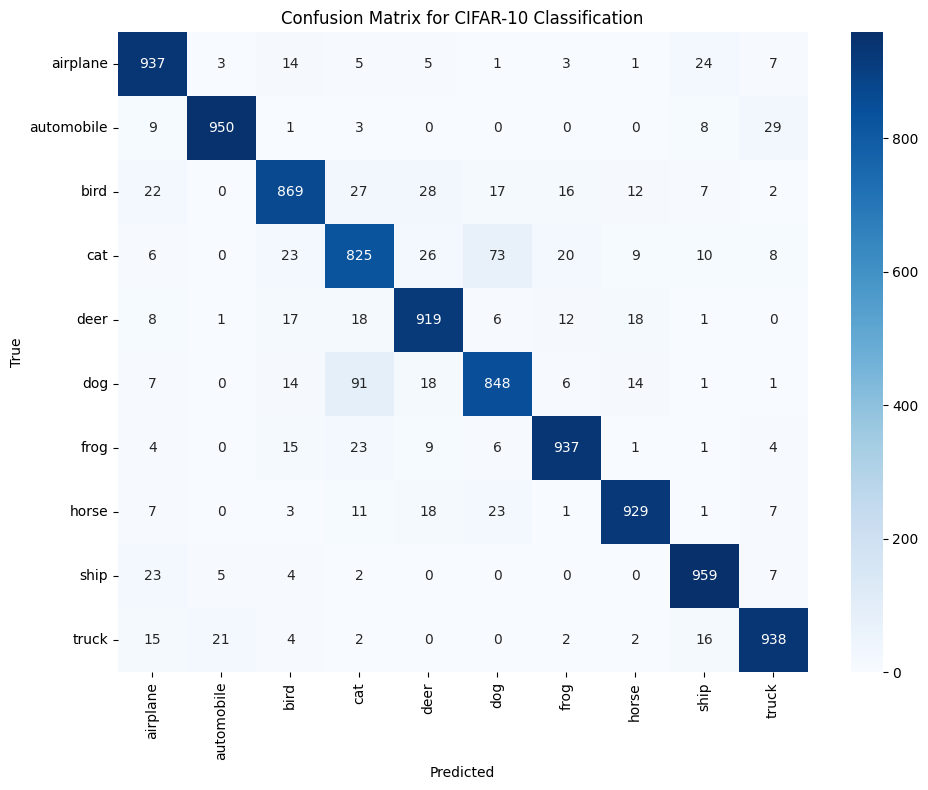

In [ ]:
if __name__ == "__main__":
    ##### YOUR CODE HERE #####
    # Implement your criterion
    criterion = nn.CrossEntropyLoss()

    model = VGG().to(DEFAULT_DEVICE)
    model = load_model(model, "./weights/best_vgg_cifar10.pth", verbose=False)
    avg_loss, test_acc, conf_matrix = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.2f}% | Loss: {avg_loss:.4f}")
    plot_confusion_matrix(conf_matrix, filename="./results/confusion_matrix.png")

## Post-Training Quantization (PTQ)
### Implement Quantization Function

In [4]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [17]:
class PowerOfTwoObserver(tq.MinMaxObserver):
    """
    Observer module for your customized customize quantization scheme.
    """

    def scale_approximate(self, scale: float, max_shift_amount=8) -> float:
        ##### YOUR CODE HERE #####
        if scale <= 1e-15:
            return 1.0

        # s = 1/(2^c) => log2(s) = -c =>
        k = round(math.log2(scale))

        # bound INT8 => -2^7 ~ 2^7-1 => symmetric => -2^7~2^7
        # maximum shift bit : 8 bits
        k = max(-max_shift_amount, min(max_shift_amount, k))

        return 2.0 ** k

    def calculate_qparams(self):
        """Calculates the quantization parameters with scale as power of two."""
        min_val, max_val = self.min_val.item(), self.max_val.item()

        """ Calculate zero_point as in the base class """
        ##### YOUR CODE HERE #####
        orig_scale, orig_zero_point = super().calculate_qparams()

        scale = orig_scale.item()
        zero_point = orig_zero_point.item()

        scale = self.scale_approximate(scale)
        scale = torch.tensor(scale, dtype=torch.float32)
        zero_point = torch.tensor(zero_point, dtype=torch.int64)
        return scale, zero_point

class CustomQConfig(Enum):
    POWER2 = tq.QConfig(
        activation=PowerOfTwoObserver.with_args(
            ##### YOUR CODE HERE #####
            dtype=torch.quint8,
            qscheme=torch.per_tensor_symmetric,
            reduce_range=False
        ),
        weight=PowerOfTwoObserver.with_args(
            ##### YOUR CODE HERE #####
            dtype=torch.qint8,
            qscheme=torch.per_tensor_symmetric,
            reduce_range=False
        ),
    )
    DEFAULT = None

### Evaluate Quantized Model

In [18]:
def test_performance(model_fp32, model_int8, dataloader, criterion,
                     fp32_file="./weights/best_vgg_cifar10.pth",
                     int8_file="./weights/PTQ_vgg_cifar10.pth" ):

    device_fp32 = 'cuda' if torch.cuda.is_available() else 'cpu'
    device_int8 = 'cpu'

    model_fp32.to(device_fp32)
    model_int8.to(device_int8)

    # ----------------------
    # Test accuracy & loss
    # ----------------------

    print("Evaluating FP32 model...")
    loss_fp32, acc_fp32, _ = evaluate(model_fp32, dataloader, criterion, device=device_fp32)
    print(f"[FP32] Loss: {loss_fp32:.4f}, Accuracy: {acc_fp32:.2f}%")

    print("Evaluating INT8 model...")
    loss_int8, acc_int8, _ = evaluate(model_int8, dataloader, criterion, device=device_int8)
    print(f"[PTQ INT8] Loss: {loss_int8:.4f}, Accuracy: {acc_int8:.2f}%")

    # ----------------------
    # Test latency
    # ----------------------
    model_fp32.to('cpu')
    dummy_input = torch.randn(1, 3, 32, 32).to('cpu')

    # FP32
    t0 = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model_fp32(dummy_input)
    t1 = time.time()
    fp32_time = (t1 - t0) / 1000

    # INT8
    t0 = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model_int8(dummy_input)
    t1 = time.time()
    int8_time = (t1 - t0) / 1000

    print(f"[Latency] FP32: {fp32_time*1000:.3f} ms | INT8: {int8_time*1000:.3f} ms")
    print(f"[Speedup] ~{fp32_time/int8_time:.2f}x faster")

    # ----------------------
    # Compare file size
    # ----------------------
    if os.path.exists(fp32_file) and os.path.exists(int8_file):
        size_fp32 = os.path.getsize(fp32_file) / 1e6
        size_int8 = os.path.getsize(int8_file) / 1e6
        print(f"[File size] FP32: {size_fp32:.2f} MB | INT8: {size_int8:.2f} MB")
        print(f"[Compression] ~{size_fp32/size_int8:.2f}x smaller")
    else:
        print("Warning: model files not found. Skipping file size comparison.")

### Run PTQ Workflow

In [19]:
 def calibrate(model, loader, device= 'cpu'):
    """
    Run one pass of calibration on the dataset to collect statistics
    for quantization (e.g., min/max values of activations).

    Args:
        model (nn.Module): The model prepared for quantization.
        loader (DataLoader): Data loader for calibration dataset.
        device (str): Device to run calibration on.
    """
    ##### YOUR CODE HERE #####
    model.eval().to(device)

    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            model(inputs)

def ptq_quantization():
    """
    Perform Post-Training Quantization (PTQ) on the trained ResNet-50 model.

    Steps:
        1. Load CIFAR-10 validation set
        2. Load trained FP32 model
        3. Fuse model layers
        4. Prepare model for PTQ
        5. Calibrate using validation data
        6. Convert model to INT8
        7. Save quantized model
    Returns:
        model_int8 (nn.Module): The INT8 quantized model after PTQ
    """
    # 1. Data
    train_loader, val_loader, _ = get_cifar10_loaders(batch_size=32, split_ratio=0.1)

    # 2. Load model (FP32 baseline)
    model_fp32 = load_model(VGG(), "./weights/best_vgg_cifar10.pth")

    ##### YOUR CODE HERE #####
    model_fp32.to('cpu')
    model_fp32.eval()

    # 3. Fuse layers
    tq.fuse_modules(model_fp32.features, [
        ['0', '1', '2'],    # Conv1
        ['4', '5', '6'],    # Conv2
        ['8', '9', '10'],   # Conv3
        ['11', '12', '13'], # Conv4
        ['14', '15', '16']  # Conv5
    ], inplace=True)

    tq.fuse_modules(model_fp32.classifier, [
        ['0', '1'], # FC6
        ['2', '3']  # FC7
    ], inplace=True)

    # 4. Prepare PTQ
    model_fp32.qconfig = CustomQConfig.POWER2.value

    tq.prepare(model_fp32, inplace=True)

    # 5. Calibrate
    calibrate(model_fp32, val_loader, device='cpu')

    # 6. Convert to INT8
    model_int8 = tq.convert(model_fp32, inplace=True)

    # 7. Save INT8 model
    save_model(model_int8, "./weights/PTQ_vgg_cifar10.pth", existed="overwrite")

    return model_int8

### Compare FP32 vs Quantized Results

In [20]:
if __name__ == "__main__":
    model_int8 = ptq_quantization()
    ##### YOUR CODE HERE #####
    # Implement your criterion
    criterion = nn.CrossEntropyLoss()

    model_baseline = load_model(VGG(), "./weights/best_vgg_cifar10.pth", verbose=True)
    test_performance(model_baseline, model_int8, test_loader, criterion)

Model loaded from ./weights/best_vgg_cifar10.pth (13.371343 MB)
Model saved at ./weights/PTQ_vgg_cifar10.pth (3.351613 MB)
Model loaded from ./weights/best_vgg_cifar10.pth (13.371343 MB)
Evaluating FP32 model...


Evaluating: 100%|██████████| 313/313 [00:03<00:00, 103.43it/s]


[FP32] Loss: 0.4043, Accuracy: 91.11%
Evaluating INT8 model...


Evaluating: 100%|██████████| 313/313 [00:28<00:00, 11.12it/s]


[PTQ INT8] Loss: 0.4174, Accuracy: 90.80%
[Latency] FP32: 7.664 ms | INT8: 3.258 ms
[Speedup] ~2.35x faster
[File size] FP32: 13.37 MB | INT8: 3.35 MB
[Compression] ~3.99x smaller
